In [2]:
import pandas as pd

df = pd.read_csv(r"D:\Python Files\projeto_etl_telecom\telecom_incidentes_raw.csv")
df.head()

,id_incidente,data_abertura,data_fechamento,regional,uf,cidade,tecnologia,tipo_incidente,prioridade,status,fornecedor,origem_chamado,tempo_resolucao_horas,sla_horas,dentro_sla,impacto_clientes,custo_material,qtd_materiais,observacao
0,INC-000001,2025-12-15 14:42:00,2025-12-16 13:01:39.681749,NE,PE,Recife,MW,Alta latência,Média,Resolvido,Fornecedor C,NOC,22.33,48,Sim,86,303.65,0,NaN
1,INC-000002,2025-11-10 21:43:00,2025-11-11 16:11:40.258071,SE,MG,Belo Horizonte,FTTH,Alta latência,Média,Resolvido,Equipe Interna,NOC,18.48,48,Sim,342,217.48,3,ok
2,INC-000003,2025-03-30 13:49:00,2025-03-31 02:36:42.976060,CO,GO,Goiânia,4G,Fibra rompida,Média,Resolvido,Fornecedor D,Cliente,12.80,48,Sim,124,2036.61,3,reincidência possível
3,INC-000004,2025-07-21 03:13:00,2025-07-21 12:51:15.539598,NE,PE,Caruaru,5G,Equipamento indisponível,Média,Resolvido,Equipe Interna,Monitoramento automático,9.64,48,Sim,216,5821.64,3,ok
4,INC-000005,2025-01-09 23:00:00,2025-01-10 22:14:20.808750,CO,DF,Samambaia,FTTH,Fibra rompida,Alta,Resolvido,Fornecedor D,Monitoramento automático,23.24,24,Sim,192,1407.21,1,ok


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8080 entries, 0 to 8079
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_incidente           8080 non-null   object 
 1   data_abertura          8080 non-null   object 
 2   data_fechamento        6390 non-null   object 
 3   regional               8080 non-null   object 
 4   uf                     8080 non-null   object 
 5   cidade                 8080 non-null   object 
 6   tecnologia             8080 non-null   object 
 7   tipo_incidente         8080 non-null   object 
 8   prioridade             8080 non-null   object 
 9   status                 8080 non-null   object 
 10  fornecedor             7919 non-null   object 
 11  origem_chamado         8080 non-null   object 
 12  tempo_resolucao_horas  6390 non-null   float64
 13  sla_horas              8080 non-null   int64  
 14  dentro_sla             6390 non-null   object 
 15  impa

In [4]:
df.describe()

,tempo_resolucao_horas,sla_horas,impacto_clientes,custo_material,qtd_materiais
count,6390.000000,8080.000000,8080.000000,7990.000000,8080.000000
mean,23.981192,43.346535,186.501609,1262.145855,1.846163
std,20.552844,20.103574,339.098145,1098.379297,1.692757
min,1.000000,8.000000,1.000000,0.000000,0.000000
25%,9.960000,24.000000,38.000000,515.622500,1.000000
50%,18.135000,48.000000,86.000000,845.625000,1.000000
75%,31.862500,48.000000,196.000000,1676.117500,3.000000
max,210.170000,72.000000,7168.000000,6765.280000,11.000000


In [5]:
df.columns

Index(['id_incidente', 'data_abertura', 'data_fechamento', 'regional', 'uf',
       'cidade', 'tecnologia', 'tipo_incidente', 'prioridade', 'status',
       'fornecedor', 'origem_chamado', 'tempo_resolucao_horas', 'sla_horas',
       'dentro_sla', 'impacto_clientes', 'custo_material', 'qtd_materiais',
       'observacao'],
      dtype='object')

In [6]:
df.isnull().sum()

id_incidente                0
data_abertura               0
data_fechamento          1690
regional                    0
uf                          0
cidade                      0
tecnologia                  0
tipo_incidente              0
prioridade                  0
status                      0
fornecedor                161
origem_chamado              0
tempo_resolucao_horas    1690
sla_horas                   0
dentro_sla               1690
impacto_clientes            0
custo_material             90
qtd_materiais               0
observacao                771
dtype: int64

In [8]:
df['data_abertura'] = pd.to_datetime(df['data_abertura'])

In [9]:
df['data_abertura'].head()

0   2025-12-15 14:42:00
1   2025-11-10 21:43:00
2   2025-03-30 13:49:00
3   2025-07-21 03:13:00
4   2025-01-09 23:00:00
Name: data_abertura, dtype: datetime64[ns]

In [10]:
df['data_fechamento'] = pd.to_datetime(df['data_fechamento'])

In [11]:
df['data_fechamento'].head()

0   2025-12-16 13:01:39.681749
1   2025-11-11 16:11:40.258071
2   2025-03-31 02:36:42.976060
3   2025-07-21 12:51:15.539598
4   2025-01-10 22:14:20.808750
Name: data_fechamento, dtype: datetime64[ns]

In [12]:
df['tempo_resolucao_calc'] = (df['data_fechamento'] - df['data_abertura']).dt.total_seconds() / 3600

In [13]:
df[['data_abertura', 'data_fechamento', 'tempo_resolucao_calc']].head()

,data_abertura,data_fechamento,tempo_resolucao_calc
0,2025-12-15 14:42:00,2025-12-16 13:01:39.681749,22.327689
1,2025-11-10 21:43:00,2025-11-11 16:11:40.258071,18.477849
2,2025-03-30 13:49:00,2025-03-31 02:36:42.976060,12.795271
3,2025-07-21 03:13:00,2025-07-21 12:51:15.539598,9.637650
4,2025-01-09 23:00:00,2025-01-10 22:14:20.808750,23.239114


In [14]:
df['fornecedor'] = df['fornecedor'].fillna('Desconhecido')

In [15]:
df['fornecedor'].isnull().sum()

np.int64(0)

In [16]:
df['custo_material'] = df['custo_material'].fillna(df['custo_material'].median())

In [17]:
df['custo_material'].isnull().sum()

np.int64(0)

In [18]:
df['cidade'] = df['cidade'].str.title()

In [19]:
df['cidade'].unique()[:10]

array(['Recife', 'Belo Horizonte', 'Goiânia', 'Caruaru', 'Samambaia',
       'Salvador', 'Taguatinga', 'Duque De Caxias', 'Boa Vista',
       'Vitória'], dtype=object)

In [20]:
df['prioridade'] = df['prioridade'].str.title()

In [21]:
df['prioridade'].unique()

array(['Média', 'Alta', 'Baixa', 'Crítica'], dtype=object)

In [22]:
df = df.drop_duplicates()

In [23]:
df.shape

(8000, 20)

In [24]:
df['dentro_sla_calc'] = df['tempo_resolucao_calc'] <= df['sla_horas']

In [25]:
df['dentro_sla_calc'].value_counts()

dentro_sla_calc
True     4732
False    3268
Name: count, dtype: int64

In [26]:
(df['dentro_sla_calc'].mean()) * 100

np.float64(59.150000000000006)

In [27]:
df.to_csv("telecom_incidentes_tratado.csv", index=False)

In [28]:
import os
os.getcwd()

'C:\\Users\\andre'

In [29]:
df.to_csv(r"D:\Python Files\projeto_etl_telecom\telecom_incidentes_tratado.csv", index=False)

In [4]:
import pandas as pd

df = pd.read_csv(r"D:\Python Files\projeto_etl_telecom\telecom_incidentes_tratado.csv")

df.head()

,id_incidente,data_abertura,data_fechamento,regional,uf,cidade,tecnologia,tipo_incidente,prioridade,status,...,origem_chamado,tempo_resolucao_horas,sla_horas,dentro_sla,impacto_clientes,custo_material,qtd_materiais,observacao,tempo_resolucao_calc,dentro_sla_calc
0,INC-000001,2025-12-15 14:42:00,2025-12-16 13:01:39.681749,NE,PE,Recife,MW,Alta latência,Média,Resolvido,...,NOC,22.33,48,Sim,86,303.65,0,NaN,22.327689,True
1,INC-000002,2025-11-10 21:43:00,2025-11-11 16:11:40.258071,SE,MG,Belo Horizonte,FTTH,Alta latência,Média,Resolvido,...,NOC,18.48,48,Sim,342,217.48,3,ok,18.477849,True
2,INC-000003,2025-03-30 13:49:00,2025-03-31 02:36:42.976060,CO,GO,Goiânia,4G,Fibra rompida,Média,Resolvido,...,Cliente,12.80,48,Sim,124,2036.61,3,reincidência possível,12.795271,True
3,INC-000004,2025-07-21 03:13:00,2025-07-21 12:51:15.539598,NE,PE,Caruaru,5G,Equipamento indisponível,Média,Resolvido,...,Monitoramento automático,9.64,48,Sim,216,5821.64,3,ok,9.637650,True
4,INC-000005,2025-01-09 23:00:00,2025-01-10 22:14:20.808750,CO,DF,Samambaia,FTTH,Fibra rompida,Alta,Resolvido,...,Monitoramento automático,23.24,24,Sim,192,1407.21,1,ok,23.239114,True


In [5]:
df_model = df.copy()

df_model = df_model.drop(columns=[
    'data_fechamento',
    'tempo_resolucao_calc'
])

In [6]:
y = df_model['dentro_sla_calc']
X = df_model.drop(columns=['dentro_sla_calc'])

In [7]:
print(X.shape)
print(y.shape)

(8000, 18)
(8000,)


In [8]:
X = pd.get_dummies(X, drop_first=True)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

modelo.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred = modelo.predict(X_test)

In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       683
        True       1.00      1.00      1.00       917

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



In [13]:
df_model = df.copy()

df_model = df_model.drop(columns=[
    'data_fechamento',
    'tempo_resolucao_calc',
    'tempo_resolucao_horas',
    'sla_horas'
])

In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       683
        True       1.00      1.00      1.00       917

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



In [15]:
df_model.columns

Index(['id_incidente', 'data_abertura', 'regional', 'uf', 'cidade',
       'tecnologia', 'tipo_incidente', 'prioridade', 'status', 'fornecedor',
       'origem_chamado', 'dentro_sla', 'impacto_clientes', 'custo_material',
       'qtd_materiais', 'observacao', 'dentro_sla_calc'],
      dtype='object')

In [28]:
y = df['dentro_sla_calc']

In [29]:
X = df.drop(columns=[
    'id_incidente',
    'dentro_sla',
    'dentro_sla_calc',
    'data_fechamento',
    'tempo_resolucao_calc',
    'tempo_resolucao_horas',
    'sla_horas',
    'status'
])

In [30]:
X = pd.get_dummies(X, drop_first=True)

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

In [33]:
modelo.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       683
        True       1.00      1.00      1.00       917

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



In [35]:
y_pred = modelo.predict(X_test)

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.77      0.53      0.63       683
        True       0.72      0.88      0.79       917

    accuracy                           0.73      1600
   macro avg       0.74      0.71      0.71      1600
weighted avg       0.74      0.73      0.72      1600



In [37]:
import pandas as pd

feature_importance = pd.Series(modelo.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

prioridade_Crítica                         0.066117
prioridade_Média                           0.065251
impacto_clientes                           0.062915
custo_material                             0.058860
prioridade_Baixa                           0.045171
qtd_materiais                              0.030064
tecnologia_FTTH                            0.012101
origem_chamado_NOC                         0.010261
origem_chamado_Monitoramento automático    0.009675
fornecedor_Equipe Interna                  0.009325
dtype: float64

In [38]:
RandomForestClassifier(class_weight='balanced')

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
modelo = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    class_weight='balanced'
)

In [40]:
modelo.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
y_pred = modelo.predict(X_test)

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.77      0.54      0.63       683
        True       0.72      0.88      0.79       917

    accuracy                           0.73      1600
   macro avg       0.74      0.71      0.71      1600
weighted avg       0.74      0.73      0.72      1600



In [43]:
y_prob = modelo.predict_proba(X_test)[:, 1]

# diminuir threshold (ex: 0.4)
y_pred_new = (y_prob > 0.4).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

       False       0.84      0.36      0.50       683
        True       0.66      0.95      0.78       917

    accuracy                           0.69      1600
   macro avg       0.75      0.65      0.64      1600
weighted avg       0.74      0.69      0.66      1600



In [44]:
for t in [0.5, 0.6, 0.7]:
    y_pred_t = (y_prob > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))


Threshold: 0.5
              precision    recall  f1-score   support

       False       0.77      0.54      0.63       683
        True       0.72      0.88      0.79       917

    accuracy                           0.73      1600
   macro avg       0.74      0.71      0.71      1600
weighted avg       0.74      0.73      0.72      1600


Threshold: 0.6
              precision    recall  f1-score   support

       False       0.72      0.64      0.68       683
        True       0.75      0.81      0.78       917

    accuracy                           0.74      1600
   macro avg       0.73      0.73      0.73      1600
weighted avg       0.74      0.74      0.74      1600


Threshold: 0.7
              precision    recall  f1-score   support

       False       0.61      0.75      0.67       683
        True       0.78      0.64      0.70       917

    accuracy                           0.69      1600
   macro avg       0.69      0.70      0.69      1600
weighted avg       0.71   

In [45]:
t = 0.6

In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[369 314]
 [112 805]]


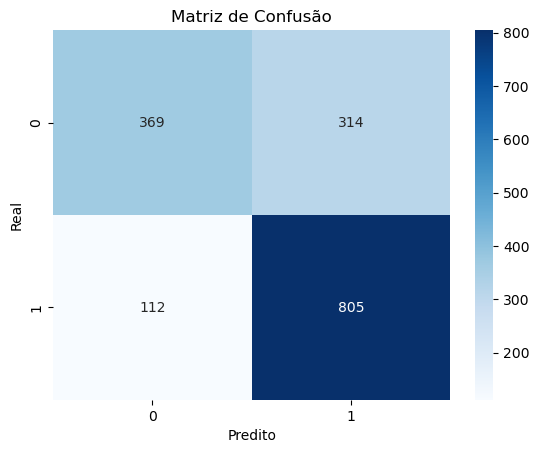

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

In [48]:
from sklearn.metrics import recall_score

recall_false = recall_score(y_test, y_pred, pos_label=0)
print("Recall da classe False (fora SLA):", recall_false)

Recall da classe False (fora SLA): 0.5402635431918009


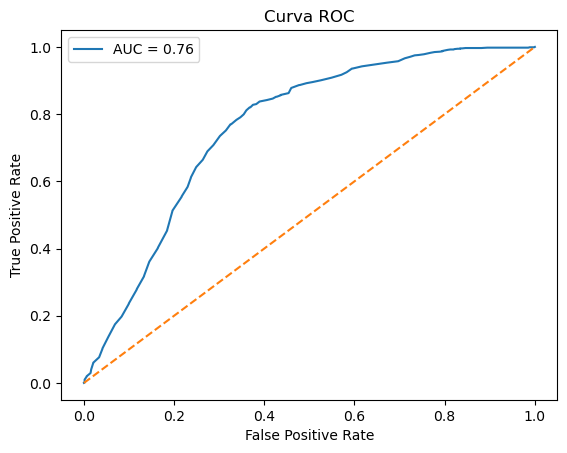

In [49]:
from sklearn.metrics import roc_curve, auc

y_prob = modelo.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()